# 17 — Pauli, Freeman–Durden & Yamaguchi-4 (Memory-Safe, v3)

This module applies the classic full-polarimetric decompositions to the same detected LSAR full-pol subset as Modules 15 and 16. The scene is processed tile-by-tile so large NISAR arrays do not trigger multi-GB eigendecomposition/decomposition allocations.

**v3 fixes:** Yamaguchi `volume_model` is handled safely for numeric and object/string outputs, and RGB visualization uses robust percentile stretching followed by explicit clipping to [0, 1]. The physical decomposition powers are never modified by the display stretch.


In [1]:
import os
import gc
import numpy as np
import matplotlib.pyplot as plt

from nisar_utils.config import load_config
from nisar_utils.polarimetric_io import (
    load_detected_mode, load_branch_terms, FULL_POL_TERMS
)
from nisar_utils.polarimetry import (
    covariance_hermitian_from_terms,
    pauli_powers,
    fullpol_freeman_durden,
    fullpol_yamaguchi4,
)


In [2]:
# ----------------------------
# Memory-safe configuration
# ----------------------------
TILE_SIZE = 512
OUTPUT_DTYPE = np.float32

def _tile_slices(nrows, ncols, tile_size=TILE_SIZE):
    for r0 in range(0, nrows, tile_size):
        r1 = min(r0 + tile_size, nrows)
        for c0 in range(0, ncols, tile_size):
            c1 = min(c0 + tile_size, ncols)
            yield r0, r1, c0, c1

def _numeric_or_label_model(values):
    """Convert Yamaguchi volume_model safely to integer codes.

    Numeric arrays are mapped directly after finite-value handling. Object/string
    labels are mapped to stable integer codes; -1 is reserved for invalid/missing.
    """
    a = np.asarray(values)
    if np.issubdtype(a.dtype, np.number):
        af = a.astype(np.float64, copy=False)
        out = np.full(a.shape, -1, dtype=np.int16)
        good = np.isfinite(af)
        if np.any(good):
            out[good] = np.rint(af[good]).astype(np.int16)
        return out, None

    # Object/string labels: do NOT call np.isfinite().
    out = np.full(a.shape, -1, dtype=np.int16)
    labels = {}
    flat = a.ravel()
    for i, value in enumerate(flat):
        if value is None:
            continue
        try:
            if isinstance(value, float) and not np.isfinite(value):
                continue
        except TypeError:
            pass
        key = str(value)
        if key.lower() in {"", "nan", "none", "null", "invalid", "missing"}:
            continue
        if key not in labels:
            labels[key] = len(labels)
        out.ravel()[i] = labels[key]
    return out, labels

def _safe_rms_sum(residual, state):
    """Accumulate RMS without retaining all residual tiles."""
    a = np.asarray(residual)
    af = np.asarray(a, dtype=np.float64)
    good = np.isfinite(af)
    state[0] += int(np.count_nonzero(good))
    if np.any(good):
        state[1] += float(np.sum(af[good] ** 2))

def _write_tile(dst, arr, r0, r1, c0, c1):
    dst[r0:r1, c0:c1] = np.asarray(arr, dtype=OUTPUT_DTYPE)

def _new_memmap(path, shape):
    if os.path.exists(path):
        os.remove(path)
    return np.memmap(path, mode="w+", dtype=OUTPUT_DTYPE, shape=shape)


In [3]:
cfg = load_config()
mode = load_detected_mode(cfg)

if mode['polarimetric_mode'] != 'LSAR_FULL_POL':
    print('SKIPPED:', mode['polarimetric_mode'])
else:
    data, sp, guard, mode = load_branch_terms(cfg, FULL_POL_TERMS)
    print('Exact v8 subset:', sp)

    # Construct C3 once to establish scene dimensions. The decomposition itself is
    # then performed tile-wise. If C3 is too large for your machine, the loader/
    # package would need a windowed reader; this notebook assumes the existing
    # branch loader can construct C3 as in Modules 15/16.
    C = covariance_hermitian_from_terms(data)
    rows, cols = C.shape[:2]
    print('C3 shape:', C.shape, 'scene:', (rows, cols), 'tile:', TILE_SIZE)

    pauli_3 = _new_memmap('module17_pauli_3.dat', (rows, cols))
    pauli_2 = _new_memmap('module17_pauli_2.dat', (rows, cols))
    pauli_1 = _new_memmap('module17_pauli_1.dat', (rows, cols))
    pauli_span = _new_memmap('module17_pauli_span.dat', (rows, cols))

    fd_db = _new_memmap('module17_fd_double_bounce.dat', (rows, cols))
    fd_v  = _new_memmap('module17_fd_volume.dat', (rows, cols))
    fd_s  = _new_memmap('module17_fd_surface.dat', (rows, cols))
    fd_res = _new_memmap('module17_fd_residual.dat', (rows, cols))

    y_db = _new_memmap('module17_y4_double_bounce.dat', (rows, cols))
    y_v  = _new_memmap('module17_y4_volume.dat', (rows, cols))
    y_s  = _new_memmap('module17_y4_surface.dat', (rows, cols))
    y_res = _new_memmap('module17_y4_residual.dat', (rows, cols))

    y4_volume_model = np.memmap(
        'module17_y4_volume_model.dat', mode='w+', dtype=np.int16, shape=(rows, cols)
    )

    fd_state = [0, 0.0]
    y4_state = [0, 0.0]
    model_labels = {}
    ntiles = ((rows + TILE_SIZE - 1)//TILE_SIZE) * ((cols + TILE_SIZE - 1)//TILE_SIZE)
    done = 0

    for r0, r1, c0, c1 in _tile_slices(rows, cols):
        Ct = np.asarray(C[r0:r1, c0:c1], dtype=np.complex64)

        pauli = pauli_powers(Ct)
        _write_tile(pauli_3, pauli['pauli_3'], r0, r1, c0, c1)
        _write_tile(pauli_2, pauli['pauli_2'], r0, r1, c0, c1)
        _write_tile(pauli_1, pauli['pauli_1'], r0, r1, c0, c1)
        _write_tile(pauli_span, pauli['span'], r0, r1, c0, c1)

        fd = fullpol_freeman_durden(Ct)
        _write_tile(fd_db, fd['double_bounce'], r0, r1, c0, c1)
        _write_tile(fd_v,  fd['volume'],       r0, r1, c0, c1)
        _write_tile(fd_s,  fd['surface'],      r0, r1, c0, c1)
        _write_tile(fd_res, fd['residual'],    r0, r1, c0, c1)
        _safe_rms_sum(fd['residual'], fd_state)

        y4 = fullpol_yamaguchi4(Ct)
        _write_tile(y_db, y4['double_bounce'], r0, r1, c0, c1)
        _write_tile(y_v,  y4['volume'],       r0, r1, c0, c1)
        _write_tile(y_s,  y4['surface'],      r0, r1, c0, c1)
        _write_tile(y_res, y4['residual'],   r0, r1, c0, c1)
        _safe_rms_sum(y4['residual'], y4_state)

        model_codes, labels = _numeric_or_label_model(y4['volume_model'])
        if labels:
            # Rebase tile-local labels into one scene-wide label dictionary.
            rebased = np.full(model_codes.shape, -1, dtype=np.int16)
            for label, local_code in labels.items():
                if label not in model_labels:
                    model_labels[label] = len(model_labels)
                rebased[model_codes == local_code] = model_labels[label]
            model_codes = rebased
        y4_volume_model[r0:r1, c0:c1] = model_codes

        done += 1
        if done == 1 or done % 10 == 0 or done == ntiles:
            print(f'Processed tile {done}/{ntiles}')

        del Ct, pauli, fd, y4, model_codes
        gc.collect()

    # Flush disk-backed products.
    for x in [pauli_3, pauli_2, pauli_1, pauli_span, fd_db, fd_v, fd_s, fd_res,
              y_db, y_v, y_s, y_res, y4_volume_model]:
        x.flush()

    fd_rms = np.sqrt(fd_state[1] / fd_state[0]) if fd_state[0] else np.nan
    y4_rms = np.sqrt(y4_state[1] / y4_state[0]) if y4_state[0] else np.nan
    print('Freeman–Durden residual RMS:', float(fd_rms))
    print('Yamaguchi-4 residual RMS:', float(y4_rms))
    print('Yamaguchi volume-model codes:', model_labels if model_labels else 'numeric codes retained')


Exact v8 subset: {'r0': 7056, 'r1': 12653, 'c0': 6459, 'c1': 11507}
C3 shape: (5597, 5048, 3, 3) scene: (5597, 5048) tile: 512
Processed tile 1/110
Processed tile 10/110
Processed tile 20/110
Processed tile 30/110
Processed tile 40/110
Processed tile 50/110
Processed tile 60/110
Processed tile 70/110
Processed tile 80/110
Processed tile 90/110
Processed tile 100/110
Processed tile 110/110
Freeman–Durden residual RMS: 6.892747199499672e-08
Yamaguchi-4 residual RMS: 5.346554299480774e-09
Yamaguchi volume-model codes: {'hh_dominant': 0, 'symmetric': 1, 'vv_dominant': 2}


RGB display stride: 4 (full-resolution products are unchanged)


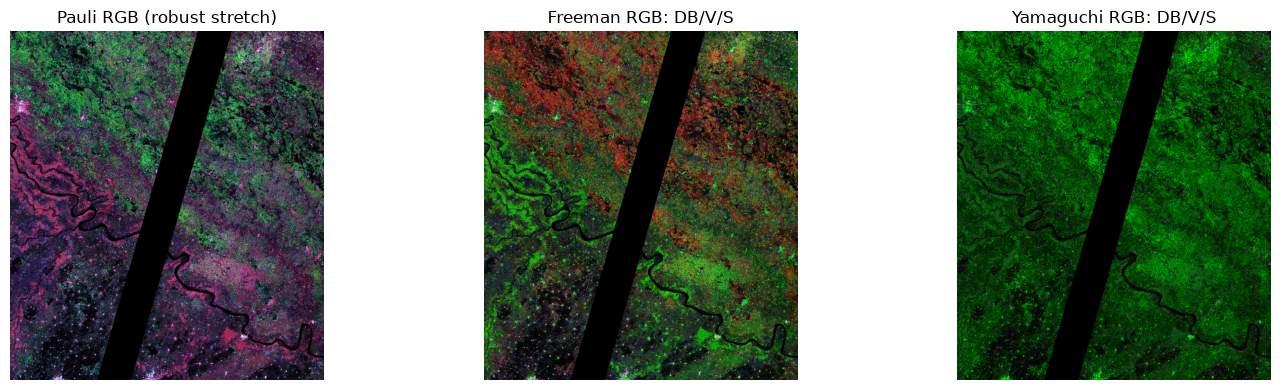

RGB visualization complete: no raw-power values are passed to imshow.
Output files are disk-backed .dat memmaps in the current working directory.


In [4]:
# ----------------------------
# Scientifically safe RGB visualization
# ----------------------------
def _finite_positive_percentile(x, q=98.0):
    a = np.asarray(x, dtype=np.float32)
    good = np.isfinite(a) & (a >= 0)
    if not np.any(good):
        return 1.0
    p = float(np.nanpercentile(a[good], q))
    return p if np.isfinite(p) and p > 0 else 1.0

def _display_rgb(channels, p_low=2.0, p_high=98.0, stride=1):
    """Create an RGB display array in [0,1] without changing source products."""
    arrays = [np.asarray(ch, dtype=np.float32) for ch in channels]
    if stride > 1:
        arrays = [a[::stride, ::stride] for a in arrays]
    out = np.empty(arrays[0].shape + (3,), dtype=np.float32)
    for k, a in enumerate(arrays):
        good = np.isfinite(a) & (a >= 0)
        if not np.any(good):
            out[..., k] = 0.0
            continue
        lo, hi = np.nanpercentile(a[good], [p_low, p_high])
        if not np.isfinite(lo): lo = 0.0
        if not np.isfinite(hi) or hi <= lo: hi = lo + 1e-12
        out[..., k] = np.clip((np.nan_to_num(a, nan=lo, posinf=hi, neginf=lo) - lo) / (hi - lo), 0.0, 1.0)
    return out

if mode['polarimetric_mode'] == 'LSAR_FULL_POL':
    # Downsample only for plotting if the scene is very large. Quantitative .dat
    # products above remain full resolution and unchanged.
    MAX_DISPLAY_PIXELS = 2_000_000
    total_pixels = rows * cols
    stride = max(1, int(np.ceil(np.sqrt(total_pixels / MAX_DISPLAY_PIXELS))))
    print('RGB display stride:', stride, '(full-resolution products are unchanged)')

    rgb_pauli = _display_rgb([pauli_3, pauli_2, pauli_1], stride=stride)
    rgb_fd = _display_rgb([fd_db, fd_v, fd_s], stride=stride)
    rgb_y4 = _display_rgb([y_db, y_v, y_s], stride=stride)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].imshow(rgb_pauli, vmin=0, vmax=1); ax[0].set_title('Pauli RGB (robust stretch)'); ax[0].axis('off')
    ax[1].imshow(rgb_fd, vmin=0, vmax=1); ax[1].set_title('Freeman RGB: DB/V/S'); ax[1].axis('off')
    ax[2].imshow(rgb_y4, vmin=0, vmax=1); ax[2].set_title('Yamaguchi RGB: DB/V/S'); ax[2].axis('off')
    plt.tight_layout(); plt.show()

    print('RGB visualization complete: no raw-power values are passed to imshow.')
    print('Output files are disk-backed .dat memmaps in the current working directory.')


## Interpretation note

The percentile stretch is **display-only**. Pauli, Freeman–Durden, and Yamaguchi power products stored in the `.dat` files retain their original quantitative values. RGB channels are independently stretched to [0,1] only to prevent Matplotlib clipping and to improve visual interpretability.
